# Linear Regression

## Simple linear regression

### Dataset description and visualisation

<b>Student Hours & Scores: </b> In this regression task we will predict the percentage of marks that a student is expected to score based upon the number of hours they studied.

<div class="alert alert-block alert-danger"> 

1. Import the student hours and scores dataset.
2. Is this task a multiple or a simple linear regression problem?
3. Which variable represents the dependent variable, and which one represents the independent variable?
4. Display the number of samples and features in the dataset.
5. Display the information about the dataset features.
6. Describe the features by displaying their statistics.
7. Plot the data and observe whether it demonstrates linear separability.
<div/>

### Dataset training and evaluation

<div class="alert alert-block alert-danger">  
    
1. Split the dataset into training and testing sets.
2. Train the data using the LinearRegression module from sklearn. 
3. Display the model's equation.
4. Create a plot showing the data and the generated model.
5. Display the performance of the generated model on the training and the test set, based on the following metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared. Does the generated model present an overfitting problem?
6. Describe the R-squared metric and its advantages compared to the other metrics.
7. Is the generated model characterized by good performance?
8. Create a plot visualizing the difference between actual and predicted values.
<div/>

## Multiple linear regression

### Data description and analysis

<b> The Boston Housing Dataset: </b> the Boston Housing Dataset is derived from information collected by the U.S. Census Service regarding housing in the Boston, Massachusetts area. It aims to predict house prices based on various characteristics. 

<div class="alert alert-block alert-danger">
    
1. Import the Boston Housing dataset.
2. Display the correlation matrix and select only the highly correlated features with the label (MEDV feature) using a threshold value of 0.6.
3. Verify if the selected features represent a linear relationship with the target variable based on a 3D plot.
from sklearn.model_selection import train_test_split
5. Normalize the data (excluding the label) using the min max scaler strategy.


<div/>

In [1]:
import pandas as pd 
data = pd.read_csv("HousingData.csv")
data.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


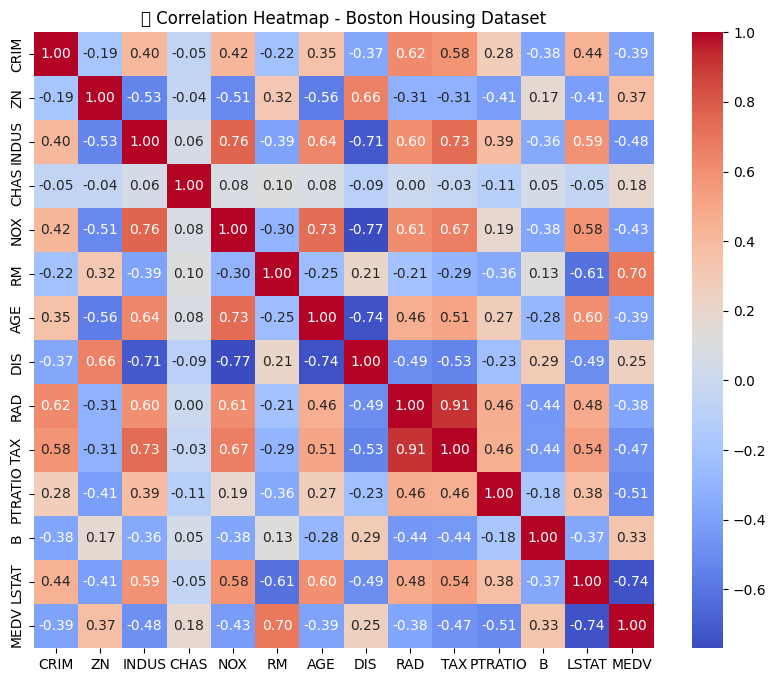

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # show correlation values
    cmap='coolwarm',     # color scheme
    fmt=".2f",           # format numbers
)
plt.title("🔗 Correlation Heatmap - Boston Housing Dataset")
plt.show()

In [17]:

corr_target = corr_matrix['MEDV'].abs()  
high_corr_features = corr_target[corr_target > 0.6]
high_corr_features

RM       0.695360
LSTAT    0.735822
MEDV     1.000000
Name: MEDV, dtype: float64

In [18]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)
data[['RM', 'LSTAT']] = imputer.fit_transform(data[['RM', 'LSTAT']])


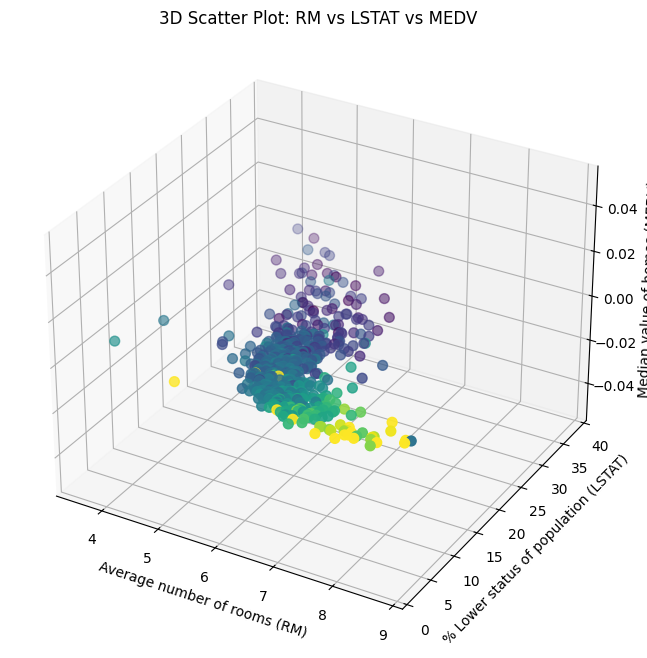

In [38]:
from mpl_toolkits.mplot3d import Axes3D 
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot data points
ax.scatter(data['RM'], data['LSTAT'], c=data['MEDV'], cmap='viridis', s=50)

# Add labels
ax.set_xlabel('Average number of rooms (RM)')
ax.set_ylabel('% Lower status of population (LSTAT)')
ax.set_zlabel('Median value of homes (MEDV)')
ax.set_title('3D Scatter Plot: RM vs LSTAT vs MEDV')

plt.show()

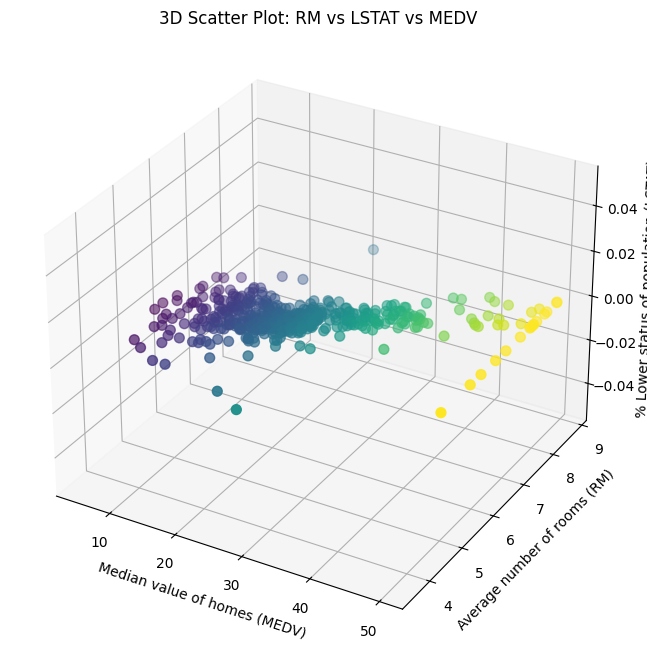

In [39]:
from mpl_toolkits.mplot3d import Axes3D 
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot data points
ax.scatter( data['MEDV'] ,data['RM'], c=data['MEDV'], cmap='viridis', s=50)

# Add labels
ax.set_ylabel('Average number of rooms (RM)')
ax.set_zlabel('% Lower status of population (LSTAT)')
ax.set_xlabel('Median value of homes (MEDV)')
ax.set_title('3D Scatter Plot: RM vs LSTAT vs MEDV')

plt.show()

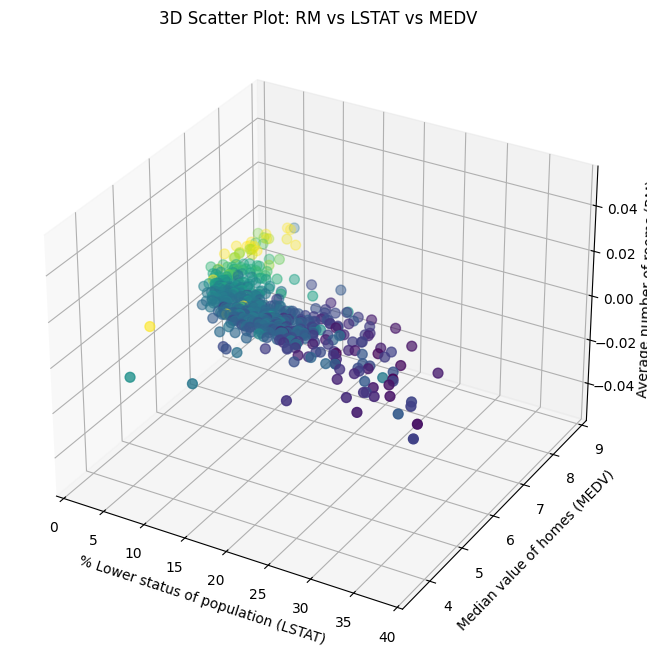

In [40]:
from mpl_toolkits.mplot3d import Axes3D 
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot data points
ax.scatter(data['LSTAT'] ,data['RM'] , c=data['MEDV'], cmap='viridis', s=50)

# Add labels
ax.set_zlabel('Average number of rooms (RM)')
ax.set_xlabel('% Lower status of population (LSTAT)')
ax.set_ylabel('Median value of homes (MEDV)')
ax.set_title('3D Scatter Plot: RM vs LSTAT vs MEDV')

plt.show()

In [41]:
from sklearn.model_selection import train_test_split

X = data[['RM', 'LSTAT']]
y = data['MEDV'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set size:", X_train.shape[0])

print("Test set size:", X_test.shape[0])
print(X_train)


Training set size: 404
Test set size: 102
        RM  LSTAT
477  5.304  24.91
15   5.834   8.47
332  6.031   7.83
423  6.103  23.29
19   5.727  11.28
..     ...    ...
106  5.836  18.66
270  5.856  13.00
348  6.635   5.99
435  6.629  23.27
102  6.405  10.63

[404 rows x 2 columns]


In [42]:
from sklearn.preprocessing import MinMaxScaler
# Create the scaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled



array([[0.29306488, 0.63962472],
       [0.40085418, 0.18598234],
       [0.44091926, 0.1683223 ],
       [0.45556233, 0.59492274],
       [0.37909294, 0.26352097],
       [0.52226968, 0.09243929],
       [0.44213952, 0.17328918],
       [0.51250763, 0.11147903],
       [0.46552776, 0.68211921],
       [0.60789099, 0.49806843],
       [0.49766118, 0.13852097],
       [0.46390075, 0.21302428],
       [0.67114094, 0.12775938],
       [0.47691682, 0.37086093],
       [0.79357332, 0.16087196],
       [0.35306081, 0.40783664],
       [0.37502542, 0.28366446],
       [0.53243848, 0.12775938],
       [0.35184055, 0.29718543],
       [0.53365874, 0.11506623],
       [0.42586943, 0.52124724],
       [0.4388855 , 0.23647903],
       [0.46898515, 0.11258278],
       [0.44295302, 0.1647351 ],
       [0.53955664, 0.12775938],
       [0.66951393, 0.0852649 ],
       [0.46552776, 0.36672185],
       [0.804759  , 0.05601545],
       [0.35590807, 0.7044702 ],
       [0.50233882, 0.15480132],
       [0.

### Data training and evaluation

<div class="alert alert-block alert-danger">
    
1. Use the following lines of code to perform training on the Boston Housing dataset.

<div/>

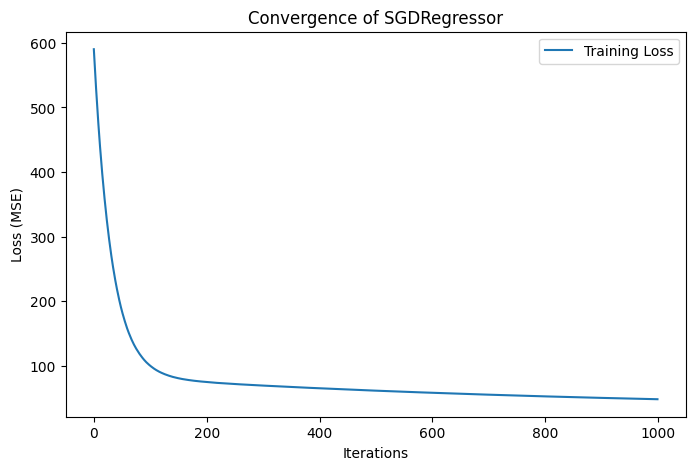

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.exceptions import ConvergenceWarning

sgdr = SGDRegressor(learning_rate='invscaling',max_iter=1,warm_start=True, eta0=0.0001,verbose=0)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
losses=[]
for i in range(1000):
    sgdr.fit(X_train_scaled, y_train)  
    y_pred = sgdr.predict(X_train_scaled)
    loss = mean_squared_error(y_train, y_pred)
    losses.append(loss)

# Plot convergence graph
plt.figure(figsize=(8,5))
plt.plot(range(len(losses)), losses, label='Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss (MSE)')
plt.title('Convergence of SGDRegressor')
plt.legend()
plt.show()

<div class="alert alert-block alert-danger">

2. Display the convergence graph of the trained model (where x represents the iterations and y is the loss).
3. Vary the learning rate value (0.01, 0.001, 0.0001). By comparing the convergence graphs for each model, what do you observe in terms of convergence and results?
4. Why does the graph not reach the maximum number of iterations when
using the 0.01 learning rate? Which variable controls this behavior?
5. Display the performance of the generated models on the test set based on the following metrics: MAE, MSE, RMSE, and R-squared. Select the best model based on these metrics.
6. Plot the generated plane of the best model and the scaled training data in one 3D plot. What do you observe?
7. Predict the class of the sample shown in the following figure based on the best model.    

<div/>

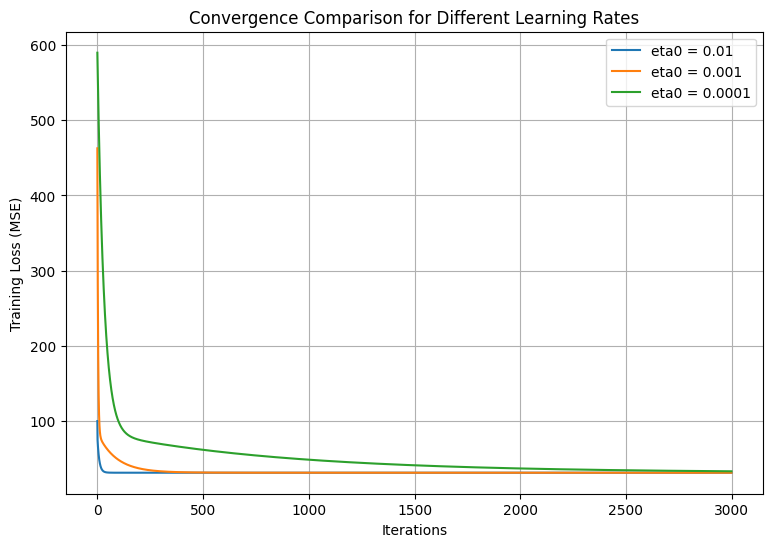

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# List of learning rates to test
learning_rates = [0.01, 0.001, 0.0001]

# Create a figure for all curves
plt.figure(figsize=(9,6))

for eta in learning_rates:
    # Initialize the SGDRegressor with given learning rate
    sgdr = SGDRegressor(
        learning_rate='invscaling',
        eta0=eta,
        max_iter=1,  # only one iteration per fit call
        warm_start=True,      # keep weights between fits
        random_state=42,
        tol= None

    )

    losses = []  # list to store loss values for this learning rate

    # Train for 1000 manual iterations
    for i in range(3000):
        sgdr.fit(X_train_scaled, y_train)
        y_pred = sgdr.predict(X_train_scaled)
        loss = mean_squared_error(y_train, y_pred)
        losses.append(loss)

 
     

    # Plot the loss curve for this learning rate
    plt.plot(losses, label=f'eta0 = {eta}')

# Add plot labels and legend
plt.xlabel('Iterations')
plt.ylabel('Training Loss (MSE)')
plt.title('Convergence Comparison for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()



When changing the learning rate, we observe that a high value (0.01) makes the training process unstable, causing large oscillations in the loss curve. However, it also allows the model to reach convergence faster, since parameter updates are larger. In contrast, a low learning rate (0.0001) results in very slow progress — the model takes tiny steps and may fail to reach the minimum loss within the given number of iterations. The intermediate learning rate (0.001) offers the best trade-off, producing a smooth and consistent decrease in loss and achieving stable convergence without overshooting.

This is because the algorithm converged early , it decided that further updates would not significantly reduce the error.
After each iteration, the optimizer checks how much the loss (error) has improved compared to the previous step.
If the improvement is smaller than tol for several consecutive iterations, it assumes the model has converged
in our case and because the learning rate is too high : 
The loss might increase, fluctuate, or fail to decrease consistently
Because the loss isn’t improving in a stable way, the optimizer sees no meaningful progress , improvement < tol.

In [13]:
results_df = pd.DataFrame(results)
print("\n📊 Model Performance Comparison:")
print(results_df.to_string(index=False))


📊 Model Performance Comparison:
 Learning Rate      MAE       MSE     RMSE       R2
        0.0100 3.865713 31.233848 5.588725 0.574086
        0.0010 3.857685 31.135084 5.579882 0.575433
        0.0001 4.536158 43.142951 6.568329 0.411691


we could see that in 0.0001 learning rate we got poor performence results MAE , MSE , RMSE are high and R2 is far from 1 and thats because 1000 iterations wasnt enough to attend the convergence and get better results 

so based on the PERFERMANCE RESULT we can see that 0.001 is the best choice , the lowest values of MAE , MSE ,RMSE and higher value of R2

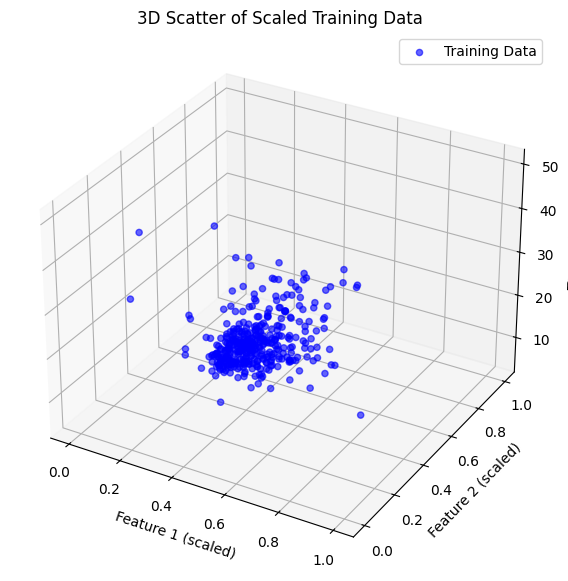

In [14]:
 

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_train_scaled[:, 0],  
    X_train_scaled[:, 1],  
    y_train,               
    color='blue',
    alpha=0.6,
    label='Training Data'
)

# Labels and title
ax.set_xlabel('Feature 1 (scaled)')
ax.set_ylabel('Feature 2 (scaled)')
ax.set_zlabel('Target (y)')
ax.set_title('3D Scatter of Scaled Training Data')
ax.legend()
plt.show()

![title](sample.png)

In [45]:


sample = pd.DataFrame([[5.713, 22.6]], columns=['RM', 'LSTAT'])
sample_scaled = scaler.transform(sample)
predicted_value = best_model.predict(sample_scaled)
print("Predicted value:", predicted_value)


Predicted value: [13.25539193]
